##### 常數

In [23]:
MODEL = "models/BlazePose/pose_landmarker_full.task"
IMG = "images/pexels-photo-4384679.jpeg"

##### 套件

In [24]:
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import cv2
import time

from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import (
    VisionTaskRunningMode,
)
from mediapipe.tasks.python.vision.pose_landmarker import (
    PoseLandmarker,
    PoseLandmarkerOptions,
    PoseLandmarkerResult,
)

from src.mediapipe_lib.base import PoseLandmarkerLiveStream, PoseResult, ResultAnalyzer
from src.utils.plot_painter import draw_lines, draw_dots

In [25]:
from matplotlib.axes import Axes
from mpl_toolkits.mplot3d.axes3d import Axes3D


##### 忽略警告

In [26]:
import warnings

warnings.filterwarnings("ignore")

##### 得到模型運算結果

In [27]:
mp_img = mp.Image.create_from_file(IMG)

option = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL),
    running_mode=VisionTaskRunningMode.IMAGE,
)

with PoseLandmarker.create_from_options(option) as landmarker:
    result = landmarker.detect(mp_img)

In [28]:
pose_result = PoseResult(result)
analyzer = ResultAnalyzer(pose_result)

##### 進行測試

In [29]:
shoulder_position = np.array(
    [
        pose_result.get_kpt_pos_by_name("left_shoulder", True),
        pose_result.get_kpt_pos_by_name("right_shoulder", True),
    ]
)
body_postion = np.array(
    [
        pose_result.get_kpt_pos_by_name("right_shoulder", True),
        pose_result.get_kpt_pos_by_name("right_hip", True),
        pose_result.get_kpt_pos_by_name("left_hip", True),
        pose_result.get_kpt_pos_by_name("left_shoulder", True),
    ]
)

center_hip_position = (
    np.array(pose_result.get_kpt_pos_by_name("left_hip", True))
    + np.array(pose_result.get_kpt_pos_by_name("right_hip", True))
) 

body_triangle_position = np.array(
    [
        pose_result.get_kpt_pos_by_name("right_shoulder", True),
        center_hip_position,
        pose_result.get_kpt_pos_by_name("left_shoulder", True),
    ]
)

center_of_gravity_position = (
    pose_result.get_kpt_pos_by_name("right_shoulder", True)
    + center_hip_position
    + pose_result.get_kpt_pos_by_name("left_shoulder", True)
) / 3

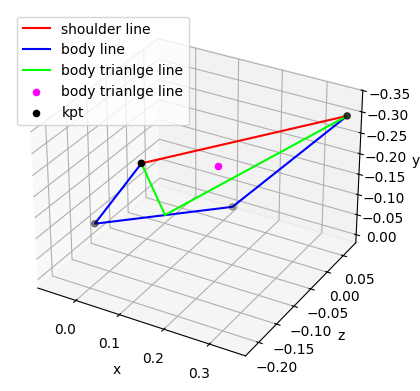

In [30]:
fig = plt.figure()
ax: Axes3D = fig.add_subplot(projection="3d")

ax.plot(
    xs=shoulder_position[:, 0],
    ys=shoulder_position[:, 2],
    zs=shoulder_position[:, 1],
    c="#f00",
    label="shoulder line",
)
ax.plot(
    xs=body_postion[:, 0],
    ys=body_postion[:, 2],
    zs=body_postion[:, 1],
    c="#00f",
    label="body line",
)
ax.plot(
    xs=body_triangle_position[:, 0],
    ys=body_triangle_position[:, 2],
    zs=body_triangle_position[:, 1],
    c="#0f0",
    label="body trianlge line",
)
ax.scatter(
    xs=center_of_gravity_position[0],
    ys=center_of_gravity_position[2],
    zs=center_of_gravity_position[1],
    c="#f0f",
    label="body trianlge line",
)
ax.scatter(
    xs=body_postion[:, 0],
    ys=body_postion[:, 2],
    zs=body_postion[:, 1],
    c="#000",
    label="kpt",
)
ax.legend()

ax.set_xlim([body_postion.min(0)[0], body_postion.max(0)[0]])
ax.set_ylim([body_postion.min(0)[2], body_postion.max(0)[2]])
ax.set_zlim([body_postion.max(0)[1], body_postion.min(0)[1]])
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_zlabel("y")

plt.show()